# Contact rate & trọng số đóng góp event (1010 / 1020)

Notebook **độc lập** — đo **tỷ lệ liên hệ thật** sau khi xem tin và **trọng số** cho từng lớp hành vi, có kiểm soát **phân phối** (không dùng % event thô làm trọng số outcome).

## Định nghĩa contact thật

| Lớp | `event_type` | Vai trò |
|-----|--------------|---------|
| **Explicit contact** | `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms` | **Outcome** — lead / doanh thu |
| **Other interaction** | `other_interaction` | Exposure (chủ yếu `surface=ad_view`) — **tách cấu thành**, không gom với explicit |
| **Pageview** | `pageview` | Browse — điều kiện “đã xem tin” |

## KPI contact rate (thứ tự ưu tiên đọc)

1. **`session_item_contact_rate_pct`** — cùng `(session_id, item_id)`: có `pageview` → có explicit contact (**khuyến nghị**).
2. **`user_contact_rate_pct`** — user login: từng có pageview → từng có explicit (bất kỳ tin).
3. **`session_explicit_rate_pct`** — session có explicit (có thể **khác tin** với pageview → chỉ tham chiếu).

## Trọng số

- **`event_volume_share_pct`**: chỉ mô tả phân phối — **không** dùng làm trọng số outcome.
- **`incremental_lift_pp`** / **`normalized_path_weight`**: đóng góp đường đi (pageview-only vs other_interaction ad_view vs other surface).
- **`logistic_abs_coef_weight`**: hồi quy logistic trên session×item (có pageview), hệ số chuẩn hóa (cẩn trọng mất cân bằng lớp).

## Quy tắc dữ liệu

- `fact_user_events`: **`is_login = 'login'`** cho mọi metric user/session.
- `dwell_time_sec` → **`dwell_time_sec / 1000`** (ms → giây); consider = pageview với dwell > 30s.
- Nhiều bảng: §0 **time coverage** `dim_listing.posted_date` vs facts; join listing kèm `posted_cohort`.

**Export:** `outputs/eda_contact_rate_weights/{category}/`


In [1]:
%matplotlib inline
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_ROOT = Path.cwd().resolve()
for name in ("dim_listing", "fact_user_events", "fact_listing_snapshot"):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

OUT_ROOT = DATA_ROOT / "outputs" / "eda_contact_rate_weights"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
# None = full scan; 0.08–0.15 nếu thiếu RAM — sample theo **session** (không random từng event)
SESSION_SAMPLE_FRAC: float | None = None
LOGISTIC_SAMPLE_FRAC = 0.04  # session×item bổ sung cho sklearn (hash session+item)

LOGIN_WHERE = "is_login = 'login'"
EXPLICIT_TYPES = ("view_phone", "contact_chat", "contact_zalo", "contact_sms")
EXPLICIT_SQL = ", ".join(repr(x) for x in EXPLICIT_TYPES)

CAT_META = {1010: "1010 — Căn hộ / Chung cư", 1020: "1020 — Nhà ở"}
CATEGORIES = (1010, 1020)

DATATHON_POSITIVE_TYPES = EXPLICIT_TYPES + ("other_interaction",)  # tham chiếu README only

con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")


def session_sample_clause(frac: float | None) -> str:
    """Giữ toàn bộ event trong session được chọn — tránh méo contact rate."""
    if frac is None:
        return ""
    if not (0 < float(frac) < 1):
        raise ValueError("SESSION_SAMPLE_FRAC phải trong (0,1)")
    bucket = max(1, int(float(frac) * 1000))
    return f"AND (abs(hash(CAST(session_id AS VARCHAR))) % 1000) < {bucket}"


def cat_out(cat: int) -> Path:
    p = OUT_ROOT / str(cat)
    p.mkdir(parents=True, exist_ok=True)
    return p


def show_df(df: pd.DataFrame, title: str, head: int | None = 30):
    display(Markdown(f"**{title}**"))
    display(df.head(head) if head else df)


def save_fig(path: Path, dpi: int = 120):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def pct_col(s: pd.Series) -> pd.Series:
    t = float(s.sum())
    return (100.0 * s / t).round(3) if t else s.astype(float)


eda_dates = con.execute(f"""
SELECT
    (SELECT MIN(date) FROM read_parquet('{EVENTS_GLOB}')) AS events_min_date,
    (SELECT MAX(date) FROM read_parquet('{EVENTS_GLOB}')) AS events_max_date,
    (SELECT MIN(date) FROM read_parquet('{SNAP_GLOB}')) AS snapshot_min_date,
    (SELECT MAX(date) FROM read_parquet('{SNAP_GLOB}')) AS snapshot_max_date,
    (SELECT MIN(posted_date) FROM read_parquet('{DIM_GLOB}') WHERE category IN (1010, 1020)) AS dim_min_posted,
    (SELECT MAX(posted_date) FROM read_parquet('{DIM_GLOB}') WHERE category IN (1010, 1020)) AS dim_max_posted
""").df().iloc[0]
EDA_MIN_DATE = eda_dates["snapshot_min_date"]
EDA_MAX_DATE = eda_dates["snapshot_max_date"]

print("OUT_ROOT =", OUT_ROOT)
print("EDA fact window:", EDA_MIN_DATE, "→", EDA_MAX_DATE)
print("dim posted:", eda_dates["dim_min_posted"], "→", eda_dates["dim_max_posted"])
print("SESSION_SAMPLE_FRAC =", SESSION_SAMPLE_FRAC)


OUT_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_contact_rate_weights
EDA fact window: 2025-11-09 00:00:00 → 2026-04-09 00:00:00
dim posted: 2024-09-15 00:00:00 → 2026-04-09 00:00:00
SESSION_SAMPLE_FRAC = None


## §0 — Time coverage (`dim_listing` vs facts)

In [2]:
time_cov = con.execute(f"""
SELECT * FROM (
    SELECT
        'dim_listing.posted_date' AS table_name,
        CAST(MIN(posted_date) AS DATE) AS min_time,
        CAST(MAX(posted_date) AS DATE) AS max_time,
        COUNT(*)::BIGINT AS n_rows
    FROM read_parquet('{DIM_GLOB}') WHERE category IN (1010, 1020)
    UNION ALL
    SELECT 'fact_user_events.date', MIN(date), MAX(date), COUNT(*)::BIGINT
    FROM read_parquet('{EVENTS_GLOB}')
    UNION ALL
    SELECT 'fact_listing_snapshot.date', MIN(date), MAX(date), COUNT(*)::BIGINT
    FROM read_parquet('{SNAP_GLOB}')
) ORDER BY 1
""").df()
show_df(time_cov, "§0 — Time coverage (dim vs facts)", head=None)
time_cov.to_csv(OUT_ROOT / "00_time_coverage.csv", index=False)

overlap = con.execute(f"""
WITH dim AS (
    SELECT CAST(item_id AS VARCHAR) AS item_id, category, posted_date,
        CASE
            WHEN posted_date IS NULL THEN 'unknown_posted'
            WHEN posted_date < DATE '{EDA_MIN_DATE}' THEN 'pre_eda_window'
            WHEN posted_date > DATE '{EDA_MAX_DATE}' THEN 'post_eda_window'
            ELSE 'in_eda_window'
        END AS posted_cohort
    FROM read_parquet('{DIM_GLOB}') WHERE category IN (1010, 1020)
),
in_ev AS (
    SELECT DISTINCT CAST(item_id AS VARCHAR) AS item_id
    FROM read_parquet('{EVENTS_GLOB}') WHERE category IN (1010, 1020)
)
SELECT category, posted_cohort,
    COUNT(*)::BIGINT AS listings,
    SUM(CASE WHEN e.item_id IS NOT NULL THEN 1 ELSE 0 END)::BIGINT AS with_events,
    ROUND(100.0 * SUM(CASE WHEN e.item_id IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_with_events
FROM dim d
LEFT JOIN in_ev e ON d.item_id = e.item_id
GROUP BY 1, 2 ORDER BY 1, 3
""").df()
show_df(overlap, "§0b — dim_listing posted_cohort × có events", head=None)
overlap.to_csv(OUT_ROOT / "00_dim_posted_cohort_overlap.csv", index=False)


**§0 — Time coverage (dim vs facts)**

,table_name,min_time,max_time,n_rows
0,dim_listing.posted_date,2024-09-15,2026-04-09,2119687
1,fact_listing_snapshot.date,2025-11-09,2026-04-09,19762167
2,fact_user_events.date,2025-11-09,2026-04-09,161731336


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**§0b — dim_listing posted_cohort × có events**

,category,posted_cohort,listings,with_events,pct_with_events
0,1010,in_eda_window,92411,89724,97.09
1,1010,pre_eda_window,519412,36463,7.02
2,1020,in_eda_window,231189,223004,96.46
3,1020,pre_eda_window,1276675,83638,6.55


## Phân tích theo category

In [3]:
def _surface_bucket(surface: str | None) -> str:
    s = (surface or "").strip().lower()
    if s == "ad_view":
        return "oi_ad_view"
    if s == "adview":
        return "oi_adview"
    if not s:
        return "oi_surface_blank"
    return f"oi_{s}"


def analyze_category(cat: int) -> None:
    label = CAT_META[cat]
    out = cat_out(cat)
    display(Markdown(f"# {label}"))
    print("Export →", out)
    samp = session_sample_clause(SESSION_SAMPLE_FRAC)

    # ── 1. Event layers (volume only — không = trọng số outcome) ─────────────
    layers = con.execute(f"""
    SELECT
        CASE
            WHEN event_type = 'pageview' THEN 'pageview'
            WHEN event_type = 'other_interaction' THEN 'other_interaction'
            WHEN event_type IN ({EXPLICIT_SQL}) THEN 'explicit_contact'
            ELSE 'other_event_type'
        END AS event_layer,
        COUNT(*)::BIGINT AS events,
        COUNT(DISTINCT user_id)::BIGINT AS users,
        COUNT(DISTINCT session_id)::BIGINT AS sessions
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} {samp}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    layers["event_volume_share_pct"] = pct_col(layers["events"])
    show_df(layers, f"{label} — Phân tầng event (volume)")
    layers.to_csv(out / "01_event_layers.csv", index=False)

    # ── 2. Cấu thành other_interaction (KHÔNG gom vào explicit) ─────────────
    oi_comp = con.execute(f"""
    SELECT
        COALESCE(NULLIF(TRIM(CAST(surface AS VARCHAR)), ''), '(blank)') AS surface,
        COALESCE(NULLIF(TRIM(CAST(device AS VARCHAR)), ''), '(blank)') AS device,
        COUNT(*)::BIGINT AS events,
        COUNT(DISTINCT session_id)::BIGINT AS sessions
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} AND event_type = 'other_interaction' {samp}
    GROUP BY 1, 2 ORDER BY events DESC
    """).df()
    oi_comp["pct_of_other_interaction"] = pct_col(oi_comp["events"])
    show_df(oi_comp, f"{label} — Cấu thành other_interaction (surface × device)")
    oi_comp.to_csv(out / "02_other_interaction_composition.csv", index=False)

    oi_surface = con.execute(f"""
    SELECT surface, COUNT(*)::BIGINT AS events
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} AND event_type = 'other_interaction' {samp}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    oi_surface["pct_of_other_interaction"] = pct_col(oi_surface["events"])

    explicit_mix = con.execute(f"""
    SELECT event_type, COUNT(*)::BIGINT AS events, COUNT(DISTINCT user_id)::BIGINT AS users
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} AND event_type IN ({EXPLICIT_SQL}) {samp}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    explicit_mix["pct_of_explicit_events"] = pct_col(explicit_mix["events"])
    show_df(explicit_mix, f"{label} — Mix explicit contact")
    explicit_mix.to_csv(out / "03_explicit_contact_mix.csv", index=False)

    # ── 3. Contact rate definitions ─────────────────────────────────────────
    rates = con.execute(f"""
    WITH ev AS (
        SELECT user_id, session_id, item_id, event_type, surface,
            CASE WHEN dwell_time_sec IS NOT NULL THEN dwell_time_sec / 1000.0 END AS dwell_sec
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE category = {cat} AND {LOGIN_WHERE} AND item_id IS NOT NULL {samp}
    ),
    session_item AS (
        SELECT session_id, item_id,
            MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_pageview,
            MAX(CASE WHEN event_type = 'other_interaction' THEN 1 ELSE 0 END) AS has_other_ix,
            MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'ad_view' THEN 1 ELSE 0 END) AS has_oi_ad_view,
            MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'adview' THEN 1 ELSE 0 END) AS has_oi_adview,
            MAX(CASE WHEN event_type = 'other_interaction'
                AND lower(coalesce(surface,'')) NOT IN ('ad_view', 'adview') THEN 1 ELSE 0 END) AS has_oi_other_surface,
            MAX(CASE WHEN event_type = 'pageview' AND dwell_sec > 30 THEN 1 ELSE 0 END) AS has_consider_pv,
            MAX(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END) AS has_explicit
        FROM ev GROUP BY 1, 2
    ),
    sess AS (
        SELECT session_id,
            MAX(has_pageview) AS has_pageview,
            MAX(has_explicit) AS has_explicit,
            MAX(has_other_ix) AS has_other_ix
        FROM session_item GROUP BY 1
    ),
    users_pv AS (
        SELECT DISTINCT user_id FROM ev WHERE event_type = 'pageview'
    ),
    users_ec AS (
        SELECT DISTINCT user_id FROM ev WHERE event_type IN ({EXPLICIT_SQL})
    )
    SELECT
        'session_item' AS grain,
        COUNT(*)::BIGINT AS n,
        SUM(has_pageview)::BIGINT AS n_with_pageview,
        SUM(CASE WHEN has_pageview = 1 AND has_explicit = 1 THEN 1 ELSE 0 END)::BIGINT AS n_contact_after_view,
        ROUND(100.0 * SUM(CASE WHEN has_pageview = 1 AND has_explicit = 1 THEN 1 ELSE 0 END)
              / NULLIF(SUM(has_pageview), 0), 3) AS contact_rate_pct,
        'explicit on SAME session+item after pageview' AS definition
    FROM session_item
    UNION ALL
    SELECT 'session', COUNT(*), SUM(has_pageview), SUM(has_explicit),
        ROUND(100.0 * SUM(has_explicit) / NULLIF(COUNT(*), 0), 3),
        'session has explicit (item may differ) — tham chiếu'
    FROM sess
    UNION ALL
    SELECT 'user', (SELECT COUNT(*) FROM users_pv), (SELECT COUNT(*) FROM users_pv),
        (SELECT COUNT(*) FROM users_pv u INNER JOIN users_ec e USING (user_id)),
        ROUND(100.0 * (SELECT COUNT(*) FROM users_pv u INNER JOIN users_ec e USING (user_id))
              / NULLIF((SELECT COUNT(*) FROM users_pv), 0), 3),
        'user ever pageview → ever explicit (any listing)'
    """).df()
    show_df(rates, f"{label} — Contact rate theo grain", head=None)
    rates.to_csv(out / "04_contact_rate_definitions.csv", index=False)

  # ── 4. Conditional rates & incremental lift (path weights) ───────────────
    path = con.execute(f"""
    WITH session_item AS (
        SELECT session_id, item_id,
            MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_pageview,
            MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'ad_view' THEN 1 ELSE 0 END) AS has_oi_ad_view,
            MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'adview' THEN 1 ELSE 0 END) AS has_oi_adview,
            MAX(CASE WHEN event_type = 'other_interaction'
                AND lower(coalesce(surface,'')) NOT IN ('ad_view', 'adview') THEN 1 ELSE 0 END) AS has_oi_other,
            MAX(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END) AS has_explicit
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE category = {cat} AND {LOGIN_WHERE} AND item_id IS NOT NULL {samp}
        GROUP BY 1, 2
    ),
    base AS (
        SELECT * FROM session_item WHERE has_pageview = 1
    )
    SELECT
        path_label,
        n_items,
        n_explicit,
        ROUND(100.0 * n_explicit / NULLIF(n_items, 0), 3) AS explicit_rate_pct
    FROM (
        SELECT 'A_pageview_only_no_other_ix' AS path_label,
            SUM(CASE WHEN has_oi_ad_view = 0 AND has_oi_adview = 0 AND has_oi_other = 0 THEN 1 ELSE 0 END) AS n_items,
            SUM(CASE WHEN has_oi_ad_view = 0 AND has_oi_adview = 0 AND has_oi_other = 0 AND has_explicit = 1 THEN 1 ELSE 0 END) AS n_explicit
        FROM base
        UNION ALL
        SELECT 'B_pageview_plus_oi_ad_view',
            SUM(CASE WHEN has_oi_ad_view = 1 THEN 1 ELSE 0 END),
            SUM(CASE WHEN has_oi_ad_view = 1 AND has_explicit = 1 THEN 1 ELSE 0 END)
        FROM base
        UNION ALL
        SELECT 'C_pageview_plus_oi_adview',
            SUM(CASE WHEN has_oi_adview = 1 THEN 1 ELSE 0 END),
            SUM(CASE WHEN has_oi_adview = 1 AND has_explicit = 1 THEN 1 ELSE 0 END)
        FROM base
        UNION ALL
        SELECT 'D_pageview_plus_oi_other_surface',
            SUM(CASE WHEN has_oi_other = 1 THEN 1 ELSE 0 END),
            SUM(CASE WHEN has_oi_other = 1 AND has_explicit = 1 THEN 1 ELSE 0 END)
        FROM base
        UNION ALL
        SELECT 'Z_all_pageview_items',
            COUNT(*), SUM(has_explicit)
        FROM base
    ) ORDER BY path_label
    """).df()
    show_df(path, f"{label} — Explicit rate theo đường đi (session×item có pageview)")
    path.to_csv(out / "05_path_conditional_rates.csv", index=False)

    rate_a = float(path.loc[path.path_label == "A_pageview_only_no_other_ix", "explicit_rate_pct"].iloc[0])
    rate_b = float(path.loc[path.path_label == "B_pageview_plus_oi_ad_view", "explicit_rate_pct"].iloc[0])
    rate_c = float(path.loc[path.path_label == "C_pageview_plus_oi_adview", "explicit_rate_pct"].iloc[0])
    rate_d = float(path.loc[path.path_label == "D_pageview_plus_oi_other_surface", "explicit_rate_pct"].iloc[0])
    rate_all = float(path.loc[path.path_label == "Z_all_pageview_items", "explicit_rate_pct"].iloc[0])

    lifts = [
        ("pageview_baseline_no_other_ix", rate_a, 0.0, "P(explicit | pv, không other_interaction)"),
        ("incremental_oi_ad_view", rate_b, rate_b - rate_a, "Δ vs A — exposure ad_view"),
        ("incremental_oi_adview", rate_c, rate_c - rate_a, "Δ vs A — surface adview"),
        ("incremental_oi_other_surface", rate_d, rate_d - rate_a, "Δ vs A — other_interaction khác surface"),
    ]
    wdf = pd.DataFrame(lifts, columns=["path_component", "conditional_explicit_rate_pct", "incremental_lift_pp", "note"])
    pos = wdf["incremental_lift_pp"].clip(lower=0)
    wdf["normalized_path_weight"] = (pos / pos.sum()).round(4) if pos.sum() > 0 else 0.0
    wdf.loc[0, "normalized_path_weight"] = np.nan  # baseline không normalize cùng lift
    show_df(wdf, f"{label} — Trọng số đường đi (lift chuẩn hóa trên phần dương)")
    wdf.to_csv(out / "06_path_incremental_weights.csv", index=False)

    # ── 5. Logistic contribution (session×item có pageview, sample) ───────────
    si = con.execute(f"""
    SELECT
        MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'ad_view' THEN 1 ELSE 0 END) AS x_oi_ad_view,
        MAX(CASE WHEN event_type = 'other_interaction' AND lower(coalesce(surface,'')) = 'adview' THEN 1 ELSE 0 END) AS x_oi_adview,
        MAX(CASE WHEN event_type = 'other_interaction'
            AND lower(coalesce(surface,'')) NOT IN ('ad_view', 'adview') THEN 1 ELSE 0 END) AS x_oi_other,
        MAX(CASE WHEN event_type = 'pageview' AND dwell_time_sec IS NOT NULL AND dwell_time_sec / 1000.0 > 30 THEN 1 ELSE 0 END) AS x_consider_pv,
        MAX(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END) AS y_explicit
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} AND item_id IS NOT NULL
      AND (abs(hash(CAST(session_id AS VARCHAR) || '|' || CAST(item_id AS VARCHAR))) % 1000) < {max(1, int(LOGISTIC_SAMPLE_FRAC * 1000))}
    GROUP BY session_id, item_id
    HAVING MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) = 1
    """).df()

    feat_cols = ["x_oi_ad_view", "x_oi_adview", "x_oi_other", "x_consider_pv"]
    X = si[feat_cols].astype(float).values
    y = si["y_explicit"].astype(int).values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    clf = LogisticRegression(max_iter=200, class_weight="balanced", random_state=42)
    clf.fit(Xs, y)
    coef = pd.DataFrame({
        "feature": feat_cols,
        "feature_label": [
            "other_interaction (surface=ad_view)",
            "other_interaction (surface=adview)",
            "other_interaction (other surface)",
            "pageview consider (dwell>30s, dwell/1000)",
        ],
        "std_coef": clf.coef_[0],
        "abs_std_coef": np.abs(clf.coef_[0]),
    })
    coef["logistic_abs_coef_weight"] = (coef["abs_std_coef"] / coef["abs_std_coef"].sum()).round(4)
    coef["intercept"] = clf.intercept_[0]
    show_df(coef, f"{label} — Logistic weights (balanced, n={len(si):,})")
    coef.to_csv(out / "07_logistic_feature_weights.csv", index=False)

    # ── 6. Event-type weight table (volume vs outcome) ─────────────────────────
    vol = layers.set_index("event_layer")["event_volume_share_pct"]
    primary_rate = float(rates.loc[rates.grain == "session_item", "contact_rate_pct"].iloc[0])
    ew = pd.DataFrame([
        ("pageview", float(vol.get("pageview", 0)), np.nan, "Browse — điều kiện xem tin; không phải outcome"),
        ("other_interaction", float(vol.get("other_interaction", 0)), float(wdf.loc[wdf.path_component == "incremental_oi_ad_view", "incremental_lift_pp"].iloc[0]),
         "Volume cao; lift ad_view — exposure, không thay explicit"),
        ("explicit_contact", float(vol.get("explicit_contact", 0)), primary_rate, "Outcome — contact rate mục tiêu"),
    ], columns=["event_layer", "event_volume_share_pct", "outcome_or_lift_pct", "interpretation"])
    show_df(ew, f"{label} — Volume share vs outcome/lift (không dùng volume làm weight)")
    ew.to_csv(out / "08_event_volume_vs_outcome.csv", index=False)

    # ── 7. Listing grain + posted_cohort (dim time alignment) ────────────────
    list_cvr = con.execute(f"""
    WITH dim AS (
        SELECT CAST(item_id AS VARCHAR) AS item_id, ad_type, posted_date,
            CASE
                WHEN posted_date IS NULL THEN 'unknown_posted'
                WHEN posted_date < DATE '{EDA_MIN_DATE}' THEN 'pre_eda_window'
                WHEN posted_date > DATE '{EDA_MAX_DATE}' THEN 'post_eda_window'
                ELSE 'in_eda_window'
            END AS posted_cohort
        FROM read_parquet('{DIM_GLOB}') WHERE category = {cat}
    ),
    ev AS (
        SELECT CAST(item_id AS VARCHAR) AS item_id,
            MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_pv,
            MAX(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END) AS has_explicit
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE category = {cat} AND {LOGIN_WHERE} {samp}
        GROUP BY 1
    )
    SELECT d.posted_cohort, d.ad_type,
        COUNT(*)::BIGINT AS listings,
        SUM(CASE WHEN e.has_pv = 1 THEN 1 ELSE 0 END)::BIGINT AS listings_with_pageview,
        SUM(CASE WHEN e.has_explicit = 1 THEN 1 ELSE 0 END)::BIGINT AS listings_with_explicit,
        ROUND(100.0 * SUM(CASE WHEN e.has_pv = 1 AND e.has_explicit = 1 THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN e.has_pv = 1 THEN 1 ELSE 0 END), 0), 3) AS listing_contact_rate_after_pv_pct
    FROM dim d
    LEFT JOIN ev e ON d.item_id = e.item_id
    GROUP BY 1, 2
    HAVING COUNT(*) >= 500
    ORDER BY 1, 2
    """).df()
    show_df(list_cvr, f"{label} — Listing CVR explicit (× dim posted_cohort)")
    list_cvr.to_csv(out / "09_listing_explicit_cvr_by_cohort_adtype.csv", index=False)

    # ── 8. Dwell (ms→s) — pageview vs other_interaction ───────────────────────
    dwell = con.execute(f"""
    SELECT event_type,
        ROUND(AVG(dwell_time_sec / 1000.0), 2) AS avg_dwell_sec,
        ROUND(quantile_cont(dwell_time_sec / 1000.0, 0.5), 2) AS p50_dwell_sec,
        ROUND(quantile_cont(dwell_time_sec / 1000.0, 0.9), 2) AS p90_dwell_sec,
        COUNT(*)::BIGINT AS n_with_dwell
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE}
      AND dwell_time_sec IS NOT NULL AND dwell_time_sec > 0
      AND event_type IN ('pageview', 'other_interaction') {samp}
    GROUP BY 1
    """).df()
    show_df(dwell, f"{label} — Dwell (đã /1000 → giây)")
    dwell.to_csv(out / "10_dwell_seconds_by_event_type.csv", index=False)

    # ── 9. Scorecard tóm tắt ───────────────────────────────────────────────────
    top_oi = str(oi_surface.iloc[0]["surface"]) if len(oi_surface) else ""
    top_oi_pct = float(oi_surface.iloc[0]["pct_of_other_interaction"]) if len(oi_surface) else 0.0
    score = pd.DataFrame([
        ("contact_rate", "session_item_after_pageview_pct", primary_rate, "KPI chính"),
        ("contact_rate", "user_ever_explicit_after_pageview_pct", float(rates.loc[rates.grain == "user", "contact_rate_pct"].iloc[0]), "User-level"),
        ("volume", "explicit_event_volume_pct", float(vol.get("explicit_contact", 0)), "~4% events — outcome"),
        ("volume", "other_interaction_event_volume_pct", float(vol.get("other_interaction", 0)), "~50% events — exposure"),
        ("composition", "other_interaction_top_surface", top_oi_pct, f"top surface={top_oi}"),
        ("weight", "incremental_lift_oi_ad_view_pp", float(wdf.loc[wdf.path_component == "incremental_oi_ad_view", "incremental_lift_pp"].iloc[0]), "vs pageview-only path"),
        ("weight", "incremental_lift_oi_adview_pp", float(wdf.loc[wdf.path_component == "incremental_oi_adview", "incremental_lift_pp"].iloc[0]), "vs pageview-only"),
    ], columns=["group", "metric", "value", "note"])
    score.to_csv(out / "11_scorecard.csv", index=False)
    show_df(score, f"{label} — Scorecard", head=None)

    # Chart: volume vs lift
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    layers_plot = layers[layers.event_layer.isin(["pageview", "other_interaction", "explicit_contact"])]
    axes[0].bar(layers_plot["event_layer"], layers_plot["event_volume_share_pct"], color=["#74c476", "#fd8d3c", "#238b45"])
    axes[0].set_title(f"{label} — Event volume % (không phải outcome weight)")
    axes[0].set_ylabel("% events"); axes[0].tick_params(axis="x", rotation=15)

    path_plot = path[path.path_label.str.startswith(("A_", "B_", "C_", "D_"))]
    axes[1].bar(path_plot["path_label"], path_plot["explicit_rate_pct"], color="#2171b5")
    axes[1].set_title("Explicit rate % theo path (session×item, có pageview)")
    axes[1].set_ylabel("%"); axes[1].tick_params(axis="x", rotation=25)
    for lbl in axes[1].get_xticklabels():
        lbl.set_ha("right")
    save_fig(out / "fig_volume_vs_path_rates.png")

    display(Markdown(
        f"**Đọc nhanh {label}:** contact rate chính **{primary_rate:.2f}%** (cùng tin trong session). "
        f"other_interaction ~**{float(vol.get('other_interaction',0)):.1f}%** event volume nhưng lift ad_view "
        f"**{float(wdf.loc[wdf.path_component=='incremental_oi_ad_view','incremental_lift_pp'].iloc[0]):.2f}pp** — không gom với explicit."
    ))


## Chạy

# 1010 — Căn hộ / Chung cư

Export → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_contact_rate_weights/1010


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Phân tầng event (volume)**

,event_layer,events,users,sessions,event_volume_share_pct
0,other_interaction,8161878,259252,782166,50.623
1,pageview,7325418,344131,1315449,45.435
2,explicit_contact,635659,88438,221662,3.943


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Dwell (đã /1000 → giây)**

,event_type,avg_dwell_sec,p50_dwell_sec,p90_dwell_sec,n_with_dwell
0,pageview,48.56,15.91,82.36,6856329


**1010 — Căn hộ / Chung cư — Scorecard**

,group,metric,value,note
0,contact_rate,session_item_after_pageview_pct,7.604,KPI chính
1,contact_rate,user_ever_explicit_after_pageview_pct,25.684,User-level
2,volume,explicit_event_volume_pct,3.943,~4% events — outcome
3,volume,other_interaction_event_volume_pct,50.623,~50% events — exposure
4,composition,other_interaction_top_surface,93.813,top surface=ad_view
5,weight,incremental_lift_oi_ad_view_pp,7.924,vs pageview-only path
6,weight,incremental_lift_oi_adview_pp,14.784,vs pageview-only


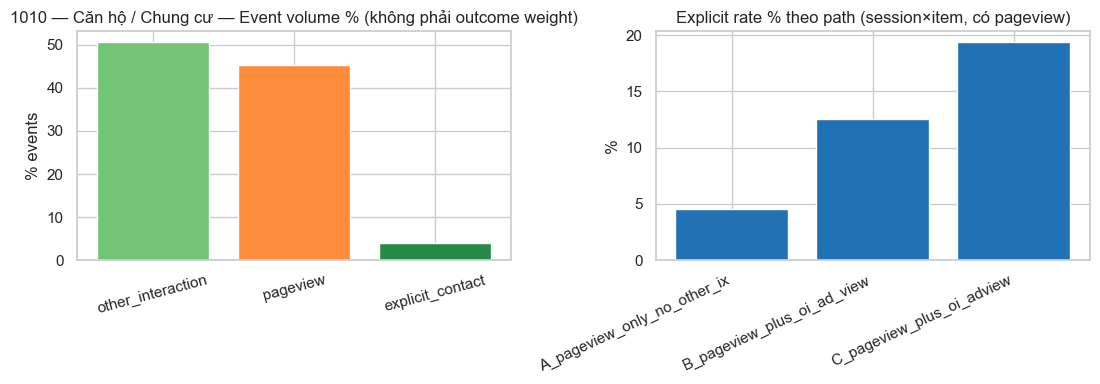

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_contact_rate_weights/1010/fig_volume_vs_path_rates.png


**Đọc nhanh 1010 — Căn hộ / Chung cư:** contact rate chính **7.60%** (cùng tin trong session). other_interaction ~**50.6%** event volume nhưng lift ad_view **7.92pp** — không gom với explicit.

# 1020 — Nhà ở

Export → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_contact_rate_weights/1020


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Dwell (đã /1000 → giây)**

,event_type,avg_dwell_sec,p50_dwell_sec,p90_dwell_sec,n_with_dwell
0,pageview,52.67,17.75,91.56,19211650


**1020 — Nhà ở — Scorecard**

,group,metric,value,note
0,contact_rate,session_item_after_pageview_pct,7.816,KPI chính
1,contact_rate,user_ever_explicit_after_pageview_pct,26.379,User-level
2,volume,explicit_event_volume_pct,4.057,~4% events — outcome
3,volume,other_interaction_event_volume_pct,50.871,~50% events — exposure
4,composition,other_interaction_top_surface,95.555,top surface=ad_view
5,weight,incremental_lift_oi_ad_view_pp,8.229,vs pageview-only path
6,weight,incremental_lift_oi_adview_pp,11.197,vs pageview-only


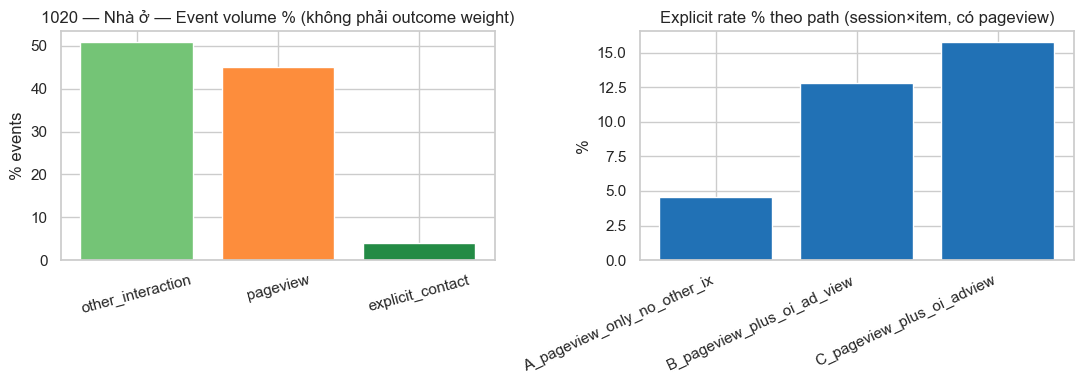

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_contact_rate_weights/1020/fig_volume_vs_path_rates.png


**Đọc nhanh 1020 — Nhà ở:** contact rate chính **7.82%** (cùng tin trong session). other_interaction ~**50.9%** event volume nhưng lift ad_view **8.23pp** — không gom với explicit.

In [4]:
for cat in CATEGORIES:
    analyze_category(cat)


---

### Cách dùng trọng số (marketing / modeling)

1. **Target / KPI:** `session_item_contact_rate_pct` + explicit mix — **không** dùng `DATATHON_POSITIVE` gom `other_interaction`.
2. **Monitoring exposure:** `other_interaction` tách `surface` (file `02_*`).
3. **Path weights (`06_*`):** ưu tiên tối ưu kênh làm tăng **incremental lift** explicit, không tối ưu volume `other_interaction`.
4. **Logistic (`07_*`):** so sánh tương đối feature khi mất cân bằng lớp; không thay thế contact rate thô.
5. **Join catalog:** `09_*` + `posted_cohort` — tin `pre_eda_window` có thể chưa có log events đủ.

**Liên quan:** `eda_category_1010_1020_behavior_deepdive.ipynb`, `eda_category_1010_1020_performance.ipynb` §0 time coverage.
